# Monte Carlo ($\pi$) Performance Benchmark Notebook

This notebook estimates \(\pi\) using a Monte Carlo method and compares runtime performance across multiple implementations:

- **Pure Python loop**
- **NumPy vectorized version**
- **Numba JIT-compiled version**
- **Numba parallel version**
- **Cython version**
- **C++ compiled version**

## Workflow

1. Define a range of sample sizes \(N\) (from small to very large).
2. Run each implementation multiple times per \(N\).
3. Compute average execution time for fair comparison.
4. Record \(\pi\) estimates and timing results.
5. Visualize scaling behavior with **log-log plots**.
6. Compare methods on a single chart.
7. Compute **parallel speedup** relative to standard Numba.
8. Identiy fastest method from the data, spoiler alert : parallel numba
9. Use the fastest method to tabulate statistical data for a range of N values
10. Plot mean pi estimate for each N and standard deviation for each N on log-log scale
11. Get Power-law fit for standard deviation as a function of N.

## Goal

Identify which implementation is fastest and how performance scales as the number of random points increases.

## 1. Pure Python Loop

N=100      pi≈3.16000000 avg_time=0.000029s
N=1000     pi≈3.14000000 avg_time=0.000295s
N=10000    pi≈3.13440000 avg_time=0.002698s
N=100000   pi≈3.14480000 avg_time=0.025689s
N=1000000  pi≈3.14042800 avg_time=0.258144s
N=10000000 pi≈3.14108560 avg_time=2.732643s
N=100000000 pi≈3.14161092 avg_time=26.962217s


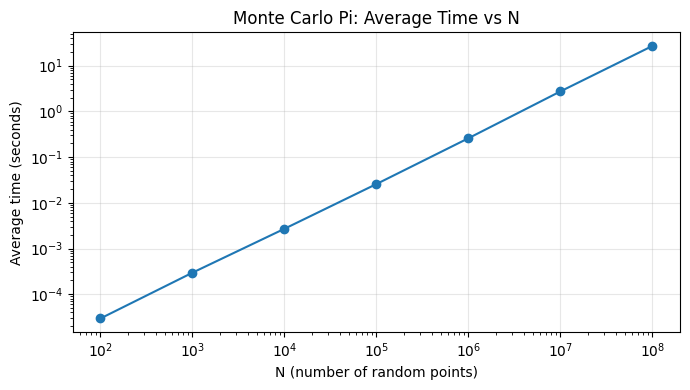

In [29]:
# Standard timing and plotting packages used for benchmarks
import timeit
import matplotlib.pyplot as plt

# Pure Python Monte Carlo implementation
from pi_python import calc_pi_loop

# Benchmark configuration: sweep N and repeat each measurement for stability
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 10
# Store per-N outputs: estimated pi and average runtime
avg_times_python = []
pi_estimates_python = []

# Run benchmark for each N
for n in n_values:
    pi_estimates_python.append(calc_pi_loop(n))
    avg_time = timeit.timeit(lambda: calc_pi_loop(n), number=repeats) / repeats
    avg_times_python.append(avg_time)

# Print a compact benchmark summary table
for n, pi_val, t in zip(n_values, pi_estimates_python, avg_times_python):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")

# Plot scaling behavior (runtime vs N) on log-log axes
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_python, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 2. Numpy vectorized version

N=100      pi≈3.04000000 avg_time=0.000018s
N=1000     pi≈3.20800000 avg_time=0.000112s
N=10000    pi≈3.11120000 avg_time=0.001235s
N=100000   pi≈3.14980000 avg_time=0.001876s
N=1000000  pi≈3.14434000 avg_time=0.010986s
N=10000000 pi≈3.14240200 avg_time=0.081851s
N=100000000 pi≈3.14151376 avg_time=0.996450s


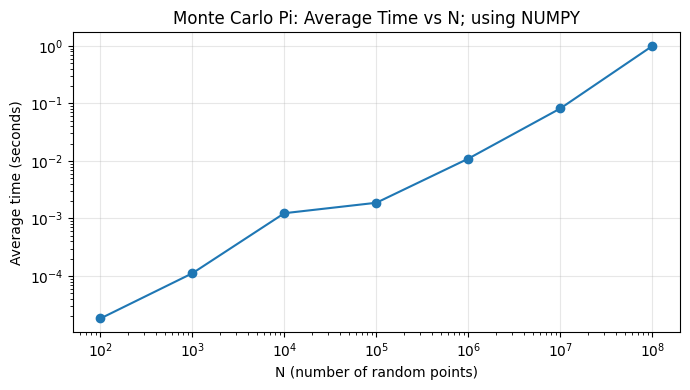

In [30]:
# NumPy vectorized Monte Carlo implementation

#Import the NumPy-based pi estimation function for benchmarking
from pi_numpy import calc_pi_numpy

# Benchmark configuration: same N sweep for cross-method comparability
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 5
# Store per-N outputs for NumPy method
avg_times_numpy = []
pi_estimates_numpy = []

# Run benchmark for each N
for n in n_values:
    pi_estimates_numpy.append(calc_pi_numpy(n))
    avg_time = timeit.timeit(lambda: calc_pi_numpy(n), number=repeats) / repeats
    avg_times_numpy.append(avg_time)

# Print per-N timing and estimate summary
for n, pi_val, t in zip(n_values, pi_estimates_numpy, avg_times_numpy):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")
# Plot NumPy scaling behavior on log-log axes
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_numpy, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using NUMPY")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Numba JIT and Numba parallel versions

N=100      pi≈2.96000000 avg_time=0.000001s
N=1000     pi≈3.15200000 avg_time=0.000010s
N=10000    pi≈3.15240000 avg_time=0.000103s
N=100000   pi≈3.14408000 avg_time=0.000932s
N=1000000  pi≈3.14104400 avg_time=0.009060s
N=10000000 pi≈3.14223240 avg_time=0.093495s
N=100000000 pi≈3.14167656 avg_time=0.904550s


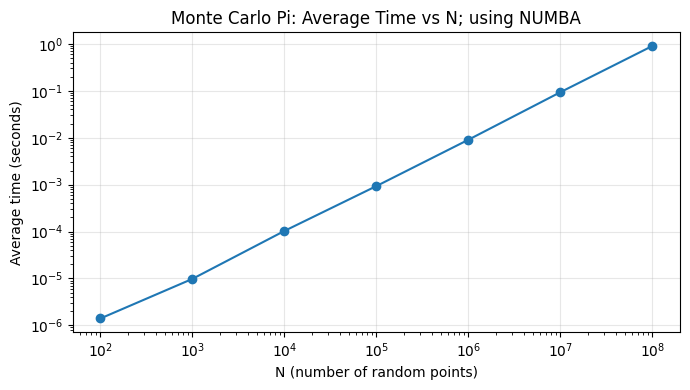

N=100      pi≈3.24000000 avg_time=0.000066s
N=1000     pi≈3.04400000 avg_time=0.000055s
N=10000    pi≈3.12640000 avg_time=0.000061s
N=100000   pi≈3.13632000 avg_time=0.000141s
N=1000000  pi≈3.14018400 avg_time=0.001168s
N=10000000 pi≈3.14062720 avg_time=0.009499s
N=100000000 pi≈3.14167452 avg_time=0.084755s


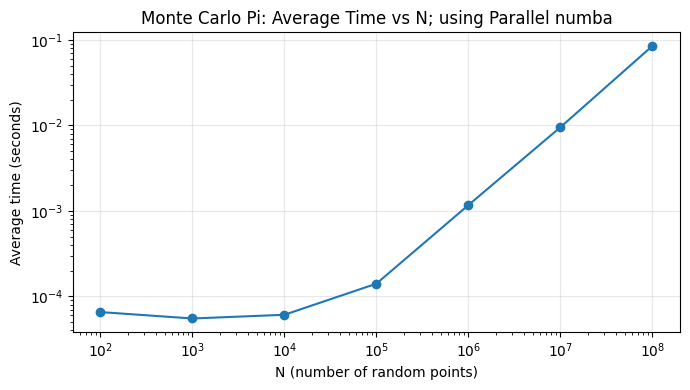

In [31]:
# Numba implementations: serial JIT and parallel variant
from pi_numba import calc_pi_numba, calc_pi_parallel

# Benchmark configuration shared by both Numba variants
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 5
# Containers for serial Numba results
avg_times_numba = []
pi_estimates_numba = []
# Run serial Numba benchmark sweep
for n in n_values:
    pi_estimates_numba.append(calc_pi_numba(n))
    avg_time = timeit.timeit(lambda: calc_pi_numba(n), number=repeats) / repeats
    avg_times_numba.append(avg_time)

# Print serial Numba results
for n, pi_val, t in zip(n_values, pi_estimates_numba, avg_times_numba):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")
# Plot serial Numba scaling
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_numba, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using NUMBA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reset result containers for parallel Numba benchmark
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]

avg_times_parallel = []
pi_estimates_parallel = []
# Run parallel Numba benchmark sweep
for n in n_values:
    pi_estimates_parallel.append(calc_pi_parallel(n))
    avg_time = timeit.timeit(lambda: calc_pi_parallel(n), number=repeats) / repeats
    avg_times_parallel.append(avg_time)

# Print parallel Numba results
for n, pi_val, t in zip(n_values, pi_estimates_parallel, avg_times_parallel):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")
# Plot parallel Numba scaling
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_parallel, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using Parallel numba")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
import numpy as np

# Compute element-wise speedup of parallel Numba over standard Numba.
# Speedup > 1 means parallel execution is faster at that N.
print("Parallel speedup:", np.array(avg_times_numba) / np.array(avg_times_parallel))

Parallel speedup: [ 0.02133871  0.17728953  1.68734454  6.61224512  7.75665594  9.84262764
 10.67258685]


## 4. C++ version 

Compiling main.cpp...
Compilation successful!

N=100      pi≈3.20000000 avg_time=0.005057s
N=1000     pi≈3.24800000 avg_time=0.004983s
N=10000    pi≈3.13240000 avg_time=0.004715s
N=100000   pi≈3.13936000 avg_time=0.005511s
N=1000000  pi≈3.14188000 avg_time=0.014576s
N=10000000 pi≈3.14086000 avg_time=0.100036s
N=100000000 pi≈3.14166000 avg_time=0.929646s


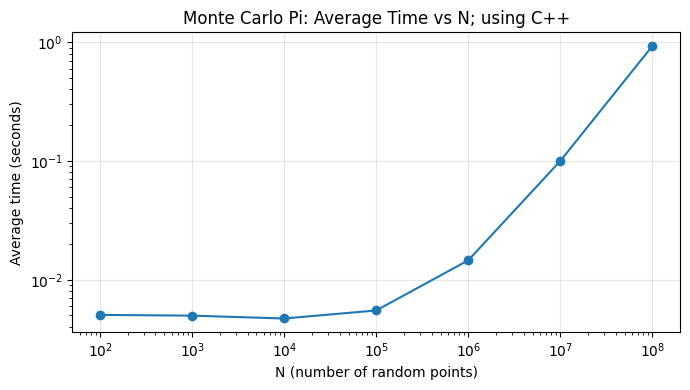

In [33]:
# Shell integration and timing helpers for C++ benchmark, suggested by co-pilot for use in Jupyter notebook environment
import subprocess
import timeit
import matplotlib.pyplot as plt 

# Compile C++ source with optimization before benchmarking
print("Compiling main.cpp...")
compile_result = subprocess.run(
    ["g++", "-O3", "-std=c++11", "main.cpp", "-o", "mc_pi"],
    capture_output=True,
    text=True
)

if compile_result.returncode != 0: #Failed compilation check
    # Show compiler errors and stop benchmark section
    print("Compilation failed:")
    print(compile_result.stderr)
else:
    print("Compilation successful!\n")
    
    # Benchmark executable across N values and track both estimate and runtime
    n_values = [ 10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
    repeats = 5
    avg_times_cpp = []
    pi_estimates_cpp = []
    
    for n in n_values:
        # Parse one run's output to capture the pi estimate reported by C++
        result = subprocess.run(
            ["./mc_pi", str(n)],
            capture_output=True,
            text=True
        )
        if result.returncode == 0:
            output = result.stdout.strip()
            pi_val = float(output.split("pi=")[1])
            pi_estimates_cpp.append(pi_val)
        
        # Average runtime over repeated launches
        avg_time = timeit.timeit(
            lambda n=n: subprocess.run(["./mc_pi", str(n)], capture_output=True, text=True),
            number=repeats
        ) / repeats
        
        avg_times_cpp.append(avg_time)
        print(f"N={n:<8d} pi≈{pi_estimates_cpp[-1]:.8f} avg_time={avg_time:.6f}s")
    
    # Plot C++ runtime scaling on log-log axes
    plt.figure(figsize=(7, 4))
    plt.plot(n_values, avg_times_cpp, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("N (number of random points)")
    plt.ylabel("Average time (seconds)")
    plt.title("Monte Carlo Pi: Average Time vs N; using C++")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Using Cyhton

In [34]:
# Dynamic import helpers for local Cython extension module, suggested by Github Copilot for use in Jupyter notebook environment
import sys
import importlib
from pathlib import Path

# Ensure local calc_pi package directory is importable
calc_pi_dir = Path("calc_pi").resolve()
if str(calc_pi_dir) not in sys.path:
    sys.path.insert(0, str(calc_pi_dir))

# Remove possibly-cached namespace package to avoid name collision
sys.modules.pop("calc_pi", None)

# Import compiled Cython function handle used in next benchmark cell
calc_pi = importlib.import_module("calc_pi")
calc_pi_cython = calc_pi.calc_pi_cython

print("Import successful, now running Cython benchmarks...")

Import successful, now running Cython benchmarks...


N=100      pi≈3.08000000 avg_time=0.000002s
N=1000     pi≈3.20000000 avg_time=0.000014s
N=10000    pi≈3.15320000 avg_time=0.000142s
N=100000   pi≈3.14800000 avg_time=0.001533s
N=1000000  pi≈3.14376000 avg_time=0.013578s
N=10000000 pi≈3.14085720 avg_time=0.134065s
N=100000000 pi≈3.14161196 avg_time=1.317479s


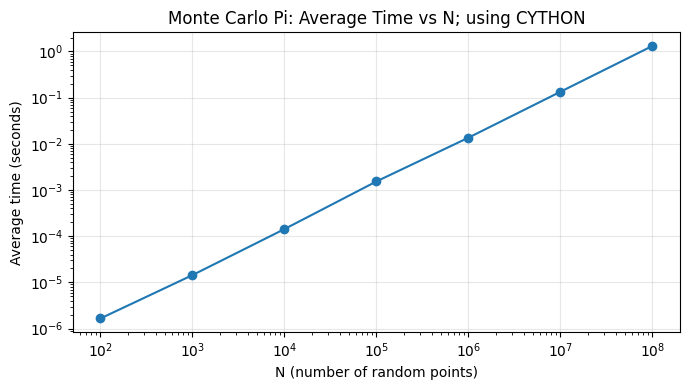

In [35]:
# Benchmark the Cython implementation.
import timeit
import matplotlib.pyplot as plt

# Use the same N values as other implementations.
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 5

# Initialize per-N outputs for Cython.
avg_times_cython = []
pi_estimates_cython = []

# Run benchmark sweep across N values.
for n in n_values:
    pi_estimates_cython.append(calc_pi_cython(n))
    avg_time = timeit.timeit(lambda n=n: calc_pi_cython(n), number=repeats) / repeats
    avg_times_cython.append(avg_time)

# Print timing and estimate summary.
for n, pi_val, t in zip(n_values, pi_estimates_cython, avg_times_cython):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")

# Plot runtime scaling for Cython on log-log axes.
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_cython, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using CYTHON")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare methods to find the fastest method

Method: python
Method: numpy
Method: numba
Method: parallel
Method: cpp
Method: cython


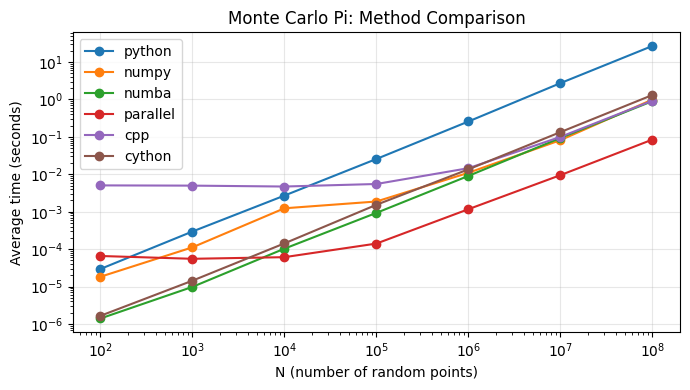

In [36]:
# Define plotting order for method comparison
methods = ['python','numpy','numba', 'parallel', 'cpp', 'cython']

# Collect timing vectors produced in earlier benchmark cells
times_by_method = {
    "python": avg_times_python,
    "numpy": avg_times_numpy,
    "numba": avg_times_numba,
    "parallel": avg_times_parallel,
    "cpp": avg_times_cpp,
    "cython": avg_times_cython,
}

# Plot all methods on the same log-log chart for fair scaling comparison
plt.figure(figsize=(7, 4))
for method in methods:
    times = times_by_method.get(method)
    if times is None:
        print(f"Skipping {method}: no timing data found.")
        continue
    print(f"Method: {method}")
    plt.plot(n_values, times, marker="o", label=method)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Method Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
# Save a copy of the comparison plot for reports
plt.savefig("../results/mc_methods_comparison.png")
plt.show()

In [37]:
# Quick side-by-side sanity benchmark at a single N
print("=" * 60)
print("Quick Benchmark")
print("=" * 60)

from time import time

# Use N = 10^8 for quick high-load comparison
logn = 8
n = 10**logn

# Methods available in current notebook session
methods_to_test = {
    "Python": calc_pi_loop,
    "NumPy": calc_pi_numpy,
    "Numba": calc_pi_numba,
    "Numba Parallel": calc_pi_parallel,
}

# Time one execution per method and print result
for method_name, method_func in methods_to_test.items():
    start = time()
    pi = method_func(n)
    end = time()
    print(f"{method_name:<18s}: π ≈ {pi:.8f}  Time: {end - start:.3f}s")

print("=" * 60)

Quick Benchmark
Python            : π ≈ 3.14137880  Time: 26.149s
NumPy             : π ≈ 3.14182232  Time: 1.206s
Numba             : π ≈ 3.14143064  Time: 0.933s
Numba Parallel    : π ≈ 3.14166392  Time: 0.080s


## Exploratory Timing Table (Five Implementations)

This section benchmarks five implementations (Python, NumPy, Numba, C++, Cython) over a small range of problem sizes to build intuition.

Recorded metrics:
- Problem size (`n`)
- Total execution time (seconds)
- Samples per second (`n / time`)
- Time per sample (`time / n`)
- Additional comments on behavior (memory/performance characteristics)

In [38]:
import pandas as pd

# Build a unified timing table across implementations
times_by_method = {
    "Python": avg_times_python,
    "NumPy": avg_times_numpy,
    "Numba": avg_times_numba,
    "Parallel": avg_times_parallel,
    "C++": avg_times_cpp,
    "Cython": avg_times_cython,
}

rows = []
for method, times in times_by_method.items():
    for n, total_time in zip(n_values, times):
        # Derive throughput and per-sample cost from total runtime
        rows.append({
            "Method": method,
            "n": n,
            "total_time_s": total_time,
            "samples_per_second": n / total_time,
            "time_per_sample_s_per_n": total_time / n,
        })

timing_df_simple = pd.DataFrame(rows)
display(timing_df_simple)

# Persist both machine-readable (CSV) and human-readable (TXT) versions
timing_df_simple.to_csv("../results/exploratory_timing_table.csv", index=False)
timing_df_simple.to_string(open("../results/exploratory_timing_table.txt", "w"), index=False)
print("Saved exploratory_timing_table.csv and exploratory_timing_table.txt")

,Method,n,total_time_s,samples_per_second,time_per_sample_s_per_n
0,Python,100,0.000029,3.395586e+06,2.945000e-07
1,Python,1000,0.000295,3.384620e+06,2.954541e-07
2,Python,10000,0.002698,3.705940e+06,2.698371e-07
3,Python,100000,0.025689,3.892674e+06,2.568928e-07
4,Python,1000000,0.258144,3.873812e+06,2.581436e-07
5,Python,10000000,2.732643,3.659461e+06,2.732643e-07
6,Python,100000000,26.962217,3.708894e+06,2.696222e-07
7,NumPy,100,0.000018,5.474473e+06,1.826660e-07
8,NumPy,1000,0.000112,8.957893e+06,1.116334e-07
9,NumPy,10000,0.001235,8.096621e+06,1.235083e-07


Saved exploratory_timing_table.csv and exploratory_timing_table.txt


# Statistical Analysis: Monte Carlo Pi Estimation Across Sample Sizes

## Objective

Generate robust statistical data for the Monte Carlo π estimation method by:
- Running **10 independent samples** for each sample size
- Testing across a wide range: **N = 10³ to 10⁹**
- Computing key metrics for each N value:
    - **π estimate** (mean across 10 samples)
    - **Absolute error** (|estimate - π|)
    - **Standard deviation** (variability across samples)
    - **Runtime** (total execution time)
    - **Time per sample** (runtime / N)
    - **Throughput** (samples processed per second)

## Output Format

Results will be stored in a structured CSV file with the following columns:

| Column | Description |
|--------|-------------|
| `n` | Number of random samples |
| `pi_estimate` | Mean π estimate across 10 runs |
| `absolute_error` | \|π_estimate - π\| |
| `std_dev` | Standard deviation of estimates |
| `runtime_sec` | Total execution time (seconds) |
| `time_per_sample` | Average time per sample (runtime / N) |
| `samples_per_sec` | Throughput (N / runtime) |

## Expected Insights

This statistical approach reveals:
- **Convergence behavior**: How estimate accuracy improves with larger N
- **Performance scaling**: Whether computational time scales linearly with N
- **Efficiency metrics**: Which N values offer best accuracy-to-cost tradeoff
- **Variability**: Statistical stability of the Monte Carlo method at different scales

In [39]:
from pi_numba import calc_pi_numba, calc_pi_parallel
import time
import numpy as np
import random

# Base seed ensures reproducible pseudo-random streams across notebook runs.
BASE_SEED = 12345

# Sweep sample sizes and run independent repeats per N.
n_values = [10**3, 10**4, 10**5, 10**6, 10**7, 10**8, 10**9, 10**10]
n_samples = 10

# Accumulators for derived statistics collected at each N.
total_runtimes = []
pi_estimate_list = []
time_per_sample = []
samples_per_second = []
abs_error_pi_list = []
std_dev_pi_list = []

for idx, n in enumerate(n_values):
    # Offset the seed by index so each N uses a deterministic but distinct stream.
    seed = BASE_SEED + idx
    random.seed(seed)
    np.random.seed(seed)

    pi_estimates = []
    time_estimates = []
    for _ in range(n_samples):
        start_time = time.perf_counter()
        pi_estimate = calc_pi_parallel(n)
        end_time = time.perf_counter()
        pi_estimates.append(pi_estimate)
        time_estimates.append(end_time - start_time)

    # Aggregate statistics for this N over n_samples runs.
    total_runtimes.append(sum(time_estimates))
    mean_pi_estimate = sum(pi_estimates) / n_samples
    pi_estimate_list.append(mean_pi_estimate)

    abs_error_pi = abs(mean_pi_estimate - np.pi)
    abs_error_pi_list.append(abs_error_pi)

    std_dev_pi = np.std(pi_estimates)
    std_dev_pi_list.append(std_dev_pi)

    avg_time = sum(time_estimates) / (n * n_samples)
    time_per_sample.append(avg_time)
    samples_per_second.append(1 / avg_time)

    print(f"N={n:<8d} seed={seed} mean π ≈ {mean_pi_estimate:.8f} abs_error={abs_error_pi:.8f} std_dev={std_dev_pi:.8f} time_per_sample={avg_time:.6f}s samples_per_second={1/avg_time:.2f}")

N=1000     seed=12345 mean π ≈ 3.17680000 abs_error=0.03520735 std_dev=0.05004958 time_per_sample=0.000000s samples_per_second=9256764.61
N=10000    seed=12346 mean π ≈ 3.14768000 abs_error=0.00608735 std_dev=0.01780229 time_per_sample=0.000000s samples_per_second=80958012.89
N=100000   seed=12347 mean π ≈ 3.14011600 abs_error=0.00147665 std_dev=0.00378437 time_per_sample=0.000000s samples_per_second=602394405.70
N=1000000  seed=12348 mean π ≈ 3.14166120 abs_error=0.00006855 std_dev=0.00146237 time_per_sample=0.000000s samples_per_second=911937069.20
N=10000000 seed=12349 mean π ≈ 3.14164620 abs_error=0.00005355 std_dev=0.00051640 time_per_sample=0.000000s samples_per_second=1111498592.71
N=100000000 seed=12350 mean π ≈ 3.14157761 abs_error=0.00001505 std_dev=0.00022824 time_per_sample=0.000000s samples_per_second=1202204661.68
N=1000000000 seed=12351 mean π ≈ 3.14159666 abs_error=0.00000400 std_dev=0.00004159 time_per_sample=0.000000s samples_per_second=1262379080.04
N=10000000000 see

In [40]:
import pandas as pd
rows = []

# Build one summary row per N from the statistics computed above
for n, pi_estimate, total_time, abs_error, std_dev, tps, sps in zip(
    n_values,
    pi_estimate_list,
    total_runtimes,
    abs_error_pi_list,
    std_dev_pi_list,
    time_per_sample,
    samples_per_second,
):
    rows.append({
        "N": n,
        "π estimate ": pi_estimate,
        "Total Runtime (s)": total_time,
        "Absolute Error of π Estimate": abs_error,
        "Standard Deviation of π Estimates": std_dev,
        "Time per Sample (s)": tps,
        "Samples per Second": sps
    })

# Display and persist the final statistical table
timing_df_simple = pd.DataFrame(rows)
display(timing_df_simple)

timing_df_simple.to_csv("../results/fastest_method_data.csv", index=False)
timing_df_simple.to_string(open("../results/fastest_method_table.txt", "w"), index=False)
print("Saved fastest_method_data.csv and fastest_method_table.txt")

,N,π estimate,Total Runtime (s),Absolute Error of π Estimate,Standard Deviation of π Estimates,Time per Sample (s),Samples per Second
0,1000,3.176800,0.001080,0.035207,0.050050,1.080291e-07,9.256765e+06
1,10000,3.147680,0.001235,0.006087,0.017802,1.235208e-08,8.095801e+07
2,100000,3.140116,0.001660,0.001477,0.003784,1.660042e-09,6.023944e+08
3,1000000,3.141661,0.010966,0.000069,0.001462,1.096567e-09,9.119371e+08
4,10000000,3.141646,0.089969,0.000054,0.000516,8.996862e-10,1.111499e+09
5,100000000,3.141578,0.831805,0.000015,0.000228,8.318051e-10,1.202205e+09
6,1000000000,3.141597,7.921551,0.000004,0.000042,7.921551e-10,1.262379e+09
7,10000000000,3.141595,88.476639,0.000002,0.000009,8.847664e-10,1.130242e+09


Saved fastest_method_data.csv and fastest_method_table.txt


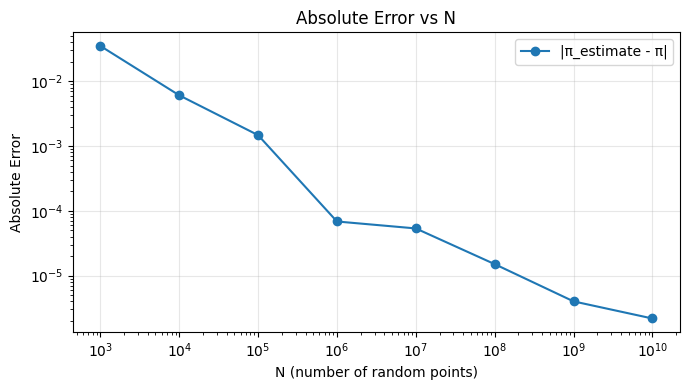

In [41]:
# Plot absolute estimation error versus sample size on log-log axes
plt.figure(figsize=(7, 4))
plt.plot(n_values, abs_error_pi_list, marker="o", label="|π_estimate - π|")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs N")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

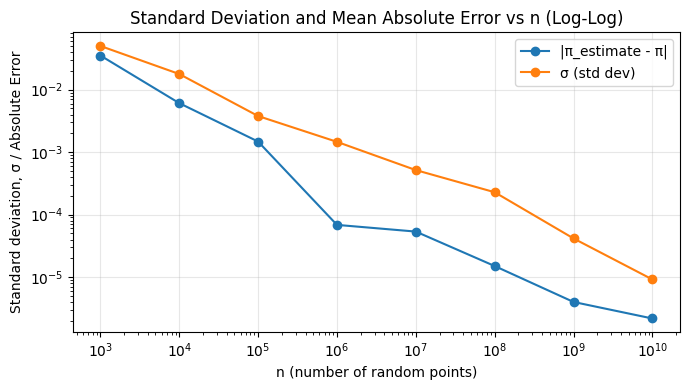

In [42]:
# Compare absolute error and sample-to-sample spread on the same axes
plt.figure(figsize=(7, 4))
plt.plot(n_values, abs_error_pi_list, marker="o", label="|π_estimate - π|")
plt.plot(n_values, std_dev_pi_list, marker="o", label="σ (std dev)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (number of random points)")
plt.ylabel("Standard deviation, σ / Absolute Error")
plt.title("Standard Deviation and Mean Absolute Error vs n (Log-Log)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
# Save figure for documentation/report inclusion
plt.savefig("../results/abs_error_std_dev_overplot.png")
plt.show()

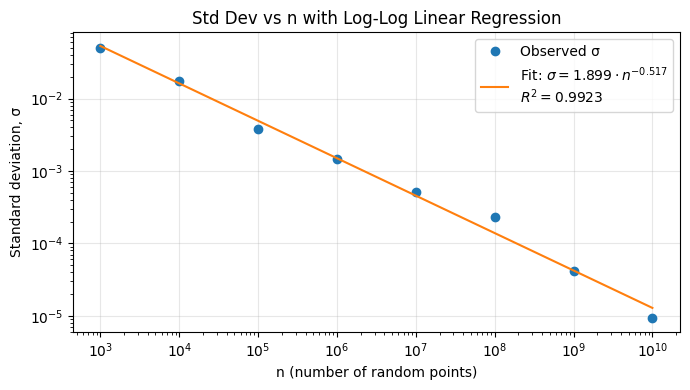

log10(σ) = -0.516976 * log10(n) + 0.278579
Power law uncertainty: ±0.018545
Intercept uncertainty: ±0.127811
Power law: σ = (1.899238e+00 ± 5.589368e-01) * n^-0.516976
R^2 (log space) = 0.992339


In [43]:
# Fit a power law σ = A * n^k by linear regression in log-log space
x = np.array(n_values, dtype=float)
y = np.array(std_dev_pi_list, dtype=float)

# Use only strictly positive values before log transform
mask = (x > 0) & (y > 0)
logx = np.log10(x[mask])
logy = np.log10(y[mask])

# Linear fit in log space: log10(σ) = k*log10(n) + b
(slope, intercept), cov = np.polyfit(logx, logy, 1, cov=True)
logy_fit = slope * logx + intercept
y_fit = 10 ** logy_fit

# Convert fitted intercept to multiplicative constant A and uncertainties
slope_err = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])
A = 10 ** intercept
A_err = A * np.log(10) * intercept_err

# Goodness of fit (R^2) computed in log domain
ss_res = np.sum((logy - logy_fit) ** 2)
ss_tot = np.sum((logy - np.mean(logy)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

# Plot observed values and fitted power-law curve
plt.figure(figsize=(7, 4))
plt.plot(x, y, "o", label="Observed σ")
plt.plot(
    x[mask],
    y_fit,
    "-",
    label=(
        f"Fit: $\\sigma = {A:.3f} \\cdot n^{{{slope:.3f}}}$\n"
        f"$R^2={r2:.4f}$"
    ),
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (number of random points)")
plt.ylabel("Standard deviation, σ")
plt.title("Std Dev vs n with Log-Log Linear Regression")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../results/fastest_method_std_dev_fit.png")
plt.show()

# Print fitted model and uncertainty summary
print(f"log10(σ) = {slope:.6f} * log10(n) + {intercept:.6f}")
print(f"Power law uncertainty: ±{slope_err:.6f}")
print(f"Intercept uncertainty: ±{intercept_err:.6f}")
print(f"Power law: σ = ({A:.6e} ± {A_err:.6e}) * n^{slope:.6f}")
print(f"R^2 (log space) = {r2:.6f}")